# Imports

In [1]:
import time
import copy
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
DATASET = "/kaggle/input/datasets/samihaahasann/grabmyo-features/grabmyo_features.csv"

features_df = pd.read_csv(DATASET)

print("Dataset Shape:", features_df.shape)

features_df.head()

Dataset Shape: (15351, 226)


,F1_mean,F1_std,F1_rms,F1_max,F1_min,F1_skew,F1_kurtosis,F2_mean,F2_std,F2_rms,...,W12_kurtosis,U4_mean,U4_std,U4_rms,U4_max,U4_min,U4_skew,U4_kurtosis,Gesture,Participant
0,-0.000007,0.047925,0.047925,0.260136,-0.339843,-0.264655,2.574033,1.090949e-05,0.064367,0.064367,...,3.683970,-0.000007,0.005259,0.005259,0.024637,-0.018634,0.068160,0.030816,10,1
1,0.000042,0.057235,0.057235,0.468627,-0.762632,-1.051270,16.942218,5.478721e-05,0.070744,0.070744,...,7.672553,0.000004,0.005121,0.005121,0.020376,-0.018360,0.062297,0.018950,10,1
2,0.000031,0.039620,0.039620,0.203892,-0.318856,-0.634328,3.795827,4.641456e-05,0.049239,0.049239,...,2.516949,0.000006,0.005027,0.005027,0.021722,-0.016988,0.032977,-0.050155,10,1
3,0.000005,0.068228,0.068228,0.448661,-0.577181,-0.588082,6.938354,1.154374e-05,0.080734,0.080734,...,2.347303,0.000004,0.005212,0.005212,0.021255,-0.019441,0.066974,0.043904,10,1
4,0.000005,0.060540,0.060540,0.292897,-0.504235,-0.421295,2.379207,9.085645e-07,0.075170,0.075170,...,4.008699,0.000006,0.005151,0.005151,0.021032,-0.019224,0.098694,0.096034,10,1


# Copy Dataset

In [3]:
model_df = features_df.copy()

# Separate Features, Labels and Participants

In [4]:
X = model_df.drop(
    columns=["Gesture", "Participant"]
)

y = model_df["Gesture"]

groups = model_df["Participant"]

print("Features:", X.shape)
print("Labels:", y.shape)
print("Participants:", groups.shape)

Features: (15351, 224)
Labels: (15351,)
Participants: (15351,)


# Train/Test Split

In [5]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

# Train/Validation Split

In [6]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx2, val_idx = next(
    gss_val.split(
        X_train,
        y_train,
        groups_train
    )
)

X_train_final = X_train.iloc[train_idx2]
X_val = X_train.iloc[val_idx]

y_train_final = y_train.iloc[train_idx2]
y_val = y_train.iloc[val_idx]

groups_train_final = groups_train.iloc[train_idx2]
groups_val = groups_train.iloc[val_idx]

# Verify Split

In [7]:
print("Training samples   :", len(X_train_final))
print("Validation samples :", len(X_val))
print("Testing samples    :", len(X_test))

print()

print("Training participants   :", groups_train_final.nunique())
print("Validation participants :", groups_val.nunique())
print("Testing participants    :", groups_test.nunique())

print()

print(
    "Train ∩ Validation:",
    len(
        set(groups_train_final)
        & set(groups_val)
    )
)

print(
    "Train ∩ Test:",
    len(
        set(groups_train_final)
        & set(groups_test)
    )
)

print(
    "Validation ∩ Test:",
    len(
        set(groups_val)
        & set(groups_test)
    )
)

Training samples   : 9639
Validation samples : 2499
Testing samples    : 3213

Training participants   : 27
Validation participants : 7
Testing participants    : 9

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


# Standardization

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_final
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

# Check Shapes

In [9]:
print("X_train:", X_train_scaled.shape)
print("X_val  :", X_val_scaled.shape)
print("X_test :", X_test_scaled.shape)

print()

print("y_train:", y_train_final.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

X_train: (9639, 224)
X_val  : (2499, 224)
X_test : (3213, 224)

y_train: (9639,)
y_val  : (2499,)
y_test : (3213,)


# PyTorch Geometric 

In [10]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00a 0:00:01


# Import GNN Libraries

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch_geometric.nn import (
    GCNConv,
    SAGEConv,
    GATConv,
    global_mean_pool,
    global_max_pool
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


# Graph Structures

In [12]:
def get_chain_graph(num_nodes=32):

    edges = []

    for i in range(num_nodes - 1):

        edges.append([i, i + 1])
        edges.append([i + 1, i])

    return torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()


def get_ring_graph(num_nodes=32):

    edges = []

    for i in range(num_nodes):

        j = (i + 1) % num_nodes

        edges.append([i, j])
        edges.append([j, i])

    return torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()


def get_skip_graph(num_nodes=32):

    edges = []

    for i in range(num_nodes - 2):

        edges.append([i, i + 2])
        edges.append([i + 2, i])

    return torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()


def get_chain_skip_graph(num_nodes=32):

    edges = []

    # Chain
    for i in range(num_nodes - 1):

        edges.append([i, i + 1])
        edges.append([i + 1, i])

    # Skip
    for i in range(num_nodes - 2):

        edges.append([i, i + 2])
        edges.append([i + 2, i])

    return torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()


def get_fully_connected_graph(num_nodes=32):

    edges = []

    for i in range(num_nodes):

        for j in range(num_nodes):

            if i != j:

                edges.append([i, j])

    return torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()

# Create All Graphs

In [13]:
graphs = {

    "Chain":
        get_chain_graph(),

    "Ring":
        get_ring_graph(),

    "Skip":
        get_skip_graph(),

    "Chain+Skip":
        get_chain_skip_graph(),

    "Fully Connected":
        get_fully_connected_graph()
}

for name, edge_index in graphs.items():

    print(
        f"{name:18s}",
        edge_index.shape
    )

Chain              torch.Size([2, 62])
Ring               torch.Size([2, 64])
Skip               torch.Size([2, 60])
Chain+Skip         torch.Size([2, 122])
Fully Connected    torch.Size([2, 992])


# Create One Graph

In [14]:
def create_graph(
    features,
    label,
    edge_index
):

    # 224 features
    # ↓
    # 32 nodes × 7 features

    x = torch.tensor(
        features.reshape(32, 7),
        dtype=torch.float
    )

    # Gesture 1–17
    # ↓
    # Class 0–16

    y = torch.tensor(
        [label - 1],
        dtype=torch.long
    )

    return Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

# Create Datasets for Every Graph

In [15]:
graph_datasets = {}

for graph_name, edge_index in graphs.items():

    train_graphs = [

        create_graph(
            x,
            y,
            edge_index
        )

        for x, y in zip(
            X_train_scaled,
            y_train_final
        )
    ]

    val_graphs = [

        create_graph(
            x,
            y,
            edge_index
        )

        for x, y in zip(
            X_val_scaled,
            y_val
        )
    ]

    test_graphs = [

        create_graph(
            x,
            y,
            edge_index
        )

        for x, y in zip(
            X_test_scaled,
            y_test
        )
    ]

    graph_datasets[graph_name] = {

        "train": train_graphs,
        "val": val_graphs,
        "test": test_graphs
    }

    print(
        f"{graph_name:18s}"
        f"Train: {len(train_graphs)}  "
        f"Val: {len(val_graphs)}  "
        f"Test: {len(test_graphs)}"
    )

Chain             Train: 9639  Val: 2499  Test: 3213
Ring              Train: 9639  Val: 2499  Test: 3213
Skip              Train: 9639  Val: 2499  Test: 3213
Chain+Skip        Train: 9639  Val: 2499  Test: 3213
Fully Connected   Train: 9639  Val: 2499  Test: 3213


# DataLoaders

In [16]:
graph_loaders = {}

for graph_name, dataset in graph_datasets.items():

    train_loader = DataLoader(
        dataset["train"],
        batch_size=32,
        shuffle=True
    )

    val_loader = DataLoader(
        dataset["val"],
        batch_size=32,
        shuffle=False
    )

    test_loader = DataLoader(
        dataset["test"],
        batch_size=32,
        shuffle=False
    )

    graph_loaders[graph_name] = {

        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }

    print(
        f"{graph_name:18s}"
        f"Train batches: {len(train_loader):3d}   "
        f"Val: {len(val_loader):3d}   "
        f"Test: {len(test_loader):3d}"
    )

Chain             Train batches: 302   Val:  79   Test: 101
Ring              Train batches: 302   Val:  79   Test: 101
Skip              Train batches: 302   Val:  79   Test: 101
Chain+Skip        Train batches: 302   Val:  79   Test: 101
Fully Connected   Train batches: 302   Val:  79   Test: 101


# GCN Model 

In [17]:
class GCN(nn.Module):

    def __init__(
        self,
        hidden1=32,
        hidden2=64,
        dropout=0.0,
        pooling="mean"
    ):

        super().__init__()

        self.conv1 = GCNConv(
            7,
            hidden1
        )

        self.conv2 = GCNConv(
            hidden1,
            hidden2
        )

        self.dropout = dropout

        self.pooling = pooling

        self.classifier = nn.Linear(
            hidden2,
            17
        )

    def forward(self, data):

        x = self.conv1(
            data.x,
            data.edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            data.edge_index
        )

        x = F.relu(x)

        if self.pooling == "mean":

            x = global_mean_pool(
                x,
                data.batch
            )

        else:

            x = global_max_pool(
                x,
                data.batch
            )

        x = self.classifier(x)

        return x

# Graph Topology Experiment

In [18]:
graph_results = []

num_epochs = 30

for graph_name, loaders in graph_loaders.items():

    print(
        "\n" + "=" * 70
    )

    print(
        f"{graph_name} Graph"
    )

    print(
        "=" * 70
    )

    model = GCN(
        hidden1=32,
        hidden2=64,
        dropout=0.0,
        pooling="mean"
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=0.0
    )

    criterion = nn.CrossEntropyLoss()

    best_val = 0.0

    best_weights = None

    start = time.time()

    for epoch in range(num_epochs):

        # =========================
        # TRAIN
        # =========================

        model.train()

        total_loss = 0

        for batch in loaders["train"]:

            batch = batch.to(device)

            optimizer.zero_grad()

            output = model(batch)

            loss = criterion(
                output,
                batch.y
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        train_loss = (
            total_loss /
            len(loaders["train"])
        )

        # =========================
        # VALIDATION
        # =========================

        model.eval()

        preds = []
        labels = []

        with torch.no_grad():

            for batch in loaders["val"]:

                batch = batch.to(device)

                output = model(batch)

                pred = output.argmax(
                    dim=1
                )

                preds.extend(
                    pred.cpu().numpy()
                )

                labels.extend(
                    batch.y.cpu().numpy()
                )

        val_acc = accuracy_score(
            labels,
            preds
        )

        if val_acc > best_val:

            best_val = val_acc

            best_weights = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    training_time = time.time() - start

    graph_results.append({

        "Graph": graph_name,

        "Validation Accuracy": best_val,

        "Training Time (s)": training_time
    })


Chain Graph
Epoch 01/30 | Loss: 2.6502 | Val Acc: 0.2025
Epoch 02/30 | Loss: 2.4699 | Val Acc: 0.2225
Epoch 03/30 | Loss: 2.4246 | Val Acc: 0.2257
Epoch 04/30 | Loss: 2.4005 | Val Acc: 0.2513
Epoch 05/30 | Loss: 2.3878 | Val Acc: 0.2465
Epoch 06/30 | Loss: 2.3745 | Val Acc: 0.2353
Epoch 07/30 | Loss: 2.3670 | Val Acc: 0.2509
Epoch 08/30 | Loss: 2.3585 | Val Acc: 0.2529
Epoch 09/30 | Loss: 2.3525 | Val Acc: 0.2381
Epoch 10/30 | Loss: 2.3480 | Val Acc: 0.2489
Epoch 11/30 | Loss: 2.3415 | Val Acc: 0.2517
Epoch 12/30 | Loss: 2.3375 | Val Acc: 0.2533
Epoch 13/30 | Loss: 2.3329 | Val Acc: 0.2421
Epoch 14/30 | Loss: 2.3271 | Val Acc: 0.2549
Epoch 15/30 | Loss: 2.3239 | Val Acc: 0.2469
Epoch 16/30 | Loss: 2.3216 | Val Acc: 0.2545
Epoch 17/30 | Loss: 2.3177 | Val Acc: 0.2645
Epoch 18/30 | Loss: 2.3171 | Val Acc: 0.2525
Epoch 19/30 | Loss: 2.3105 | Val Acc: 0.2509
Epoch 20/30 | Loss: 2.3044 | Val Acc: 0.2449
Epoch 21/30 | Loss: 2.3057 | Val Acc: 0.2489
Epoch 22/30 | Loss: 2.3018 | Val Acc: 0.24

# Graph Results Table

In [19]:
graph_results_df = pd.DataFrame(
    graph_results
)

graph_results_df = graph_results_df.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)

graph_results_df = graph_results_df.round(4)

graph_results_df

,Graph,Validation Accuracy,Training Time (s)
0,Chain+Skip,0.2729,58.5668
1,Chain,0.2645,59.2900
2,Ring,0.2605,58.0163
3,Skip,0.2561,57.4245
4,Fully Connected,0.2313,63.1632


# Automatically Select Best Graph

In [20]:
best_graph_name = graph_results_df.iloc[0][
    "Graph"
]

best_graph_accuracy = graph_results_df.iloc[0][
    "Validation Accuracy"
]

print("=" * 70)
print("BEST GRAPH STRUCTURE")
print("=" * 70)

print(
    f"Graph               : {best_graph_name}"
)

print(
    f"Validation Accuracy : "
    f"{best_graph_accuracy:.4f}"
)

BEST GRAPH STRUCTURE
Graph               : Chain+Skip
Validation Accuracy : 0.2729


# Graph Comparison Plot

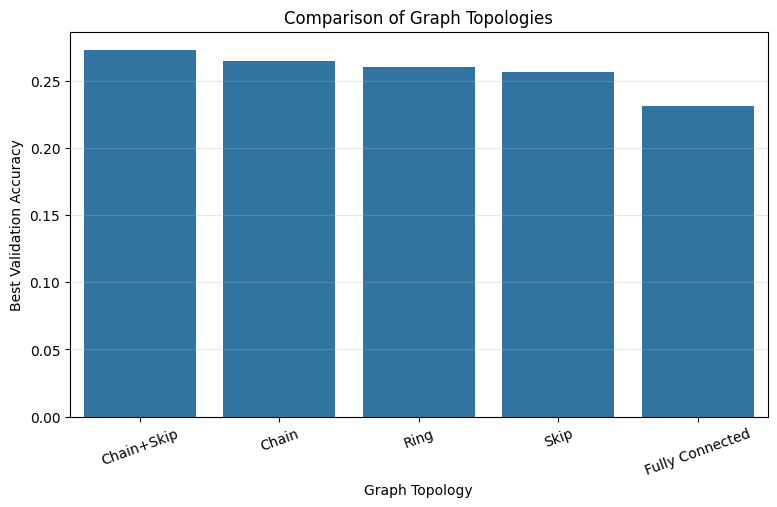

In [21]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=graph_results_df,
    x="Graph",
    y="Validation Accuracy"
)

plt.title(
    "Comparison of Graph Topologies"
)

plt.xlabel(
    "Graph Topology"
)

plt.ylabel(
    "Best Validation Accuracy"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# Select Best Graph Loaders

In [22]:
train_loader = graph_loaders[
    best_graph_name
]["train"]

val_loader = graph_loaders[
    best_graph_name
]["val"]

test_loader = graph_loaders[
    best_graph_name
]["test"]

print(
    "Using Best Graph:",
    best_graph_name
)

Using Best Graph: Chain+Skip


# Train FINAL Original GCN

In [23]:
original_gcn = GCN(
    hidden1=32,
    hidden2=64,
    dropout=0.0,
    pooling="mean"
).to(device)

optimizer = torch.optim.Adam(
    original_gcn.parameters(),
    lr=0.001,
    weight_decay=0.0
)

criterion = nn.CrossEntropyLoss()

best_val = 0.0

best_weights = None

start = time.time()

num_epochs = 30

for epoch in range(num_epochs):

    # =========================
    # TRAIN
    # =========================

    original_gcn.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = original_gcn(batch)

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = (
        total_loss /
        len(train_loader)
    )

    # =========================
    # VALIDATION
    # =========================

    original_gcn.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for batch in val_loader:

            batch = batch.to(device)

            output = original_gcn(batch)

            pred = output.argmax(
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            labels.extend(
                batch.y.cpu().numpy()
            )

    val_acc = accuracy_score(
        labels,
        preds
    )

    if val_acc > best_val:

        best_val = val_acc

        best_weights = copy.deepcopy(
            original_gcn.state_dict()
        )

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

gcn_training_time = time.time() - start

# Load BEST validation weights
original_gcn.load_state_dict(
    best_weights
)

print()
print(
    "Best GCN Validation Accuracy:",
    round(best_val, 4)
)

print(
    "Training Time:",
    round(gcn_training_time, 2),
    "seconds"
)

Epoch 01/30 | Loss: 2.6540 | Val Acc: 0.1757
Epoch 02/30 | Loss: 2.4731 | Val Acc: 0.1989
Epoch 03/30 | Loss: 2.4281 | Val Acc: 0.2149
Epoch 04/30 | Loss: 2.4054 | Val Acc: 0.2213
Epoch 05/30 | Loss: 2.3932 | Val Acc: 0.2297
Epoch 06/30 | Loss: 2.3824 | Val Acc: 0.2353
Epoch 07/30 | Loss: 2.3770 | Val Acc: 0.2433
Epoch 08/30 | Loss: 2.3669 | Val Acc: 0.2333
Epoch 09/30 | Loss: 2.3627 | Val Acc: 0.2261
Epoch 10/30 | Loss: 2.3535 | Val Acc: 0.2205
Epoch 11/30 | Loss: 2.3501 | Val Acc: 0.2393
Epoch 12/30 | Loss: 2.3425 | Val Acc: 0.2341
Epoch 13/30 | Loss: 2.3388 | Val Acc: 0.2461
Epoch 14/30 | Loss: 2.3342 | Val Acc: 0.2525
Epoch 15/30 | Loss: 2.3331 | Val Acc: 0.2433
Epoch 16/30 | Loss: 2.3265 | Val Acc: 0.2485
Epoch 17/30 | Loss: 2.3239 | Val Acc: 0.2541
Epoch 18/30 | Loss: 2.3199 | Val Acc: 0.2505
Epoch 19/30 | Loss: 2.3146 | Val Acc: 0.2477
Epoch 20/30 | Loss: 2.3129 | Val Acc: 0.2545
Epoch 21/30 | Loss: 2.3070 | Val Acc: 0.2481
Epoch 22/30 | Loss: 2.3044 | Val Acc: 0.2337
Epoch 23/3

# GraphSAGE Model

In [24]:
class GraphSAGE(nn.Module):

    def __init__(
        self,
        hidden1=32,
        hidden2=64,
        dropout=0.0,
        pooling="mean"
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            7,
            hidden1
        )

        self.conv2 = SAGEConv(
            hidden1,
            hidden2
        )

        self.dropout = dropout

        self.pooling = pooling

        self.classifier = nn.Linear(
            hidden2,
            17
        )

    def forward(self, data):

        x = self.conv1(
            data.x,
            data.edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            data.edge_index
        )

        x = F.relu(x)

        if self.pooling == "mean":

            x = global_mean_pool(
                x,
                data.batch
            )

        else:

            x = global_max_pool(
                x,
                data.batch
            )

        x = self.classifier(x)

        return x

# Train GraphSAGE

In [25]:
graphsage_model = GraphSAGE(
    hidden1=32,
    hidden2=64,
    dropout=0.0,
    pooling="mean"
).to(device)

optimizer = torch.optim.Adam(
    graphsage_model.parameters(),
    lr=0.001,
    weight_decay=0.0
)

criterion = nn.CrossEntropyLoss()

best_val = 0.0

best_weights = None

start = time.time()

for epoch in range(30):

    # TRAIN

    graphsage_model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = graphsage_model(batch)

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = (
        total_loss /
        len(train_loader)
    )

    # VALIDATION

    graphsage_model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for batch in val_loader:

            batch = batch.to(device)

            output = graphsage_model(batch)

            pred = output.argmax(
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            labels.extend(
                batch.y.cpu().numpy()
            )

    val_acc = accuracy_score(
        labels,
        preds
    )

    if val_acc > best_val:

        best_val = val_acc

        best_weights = copy.deepcopy(
            graphsage_model.state_dict()
        )

    print(
        f"Epoch {epoch+1:02d}/30 | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

graphsage_training_time = (
    time.time() - start
)

graphsage_model.load_state_dict(
    best_weights
)

graphsage_best_val = best_val

Epoch 01/30 | Loss: 2.6050 | Val Acc: 0.1905
Epoch 02/30 | Loss: 2.4388 | Val Acc: 0.2277
Epoch 03/30 | Loss: 2.3915 | Val Acc: 0.2341
Epoch 04/30 | Loss: 2.3569 | Val Acc: 0.2633
Epoch 05/30 | Loss: 2.3298 | Val Acc: 0.2629
Epoch 06/30 | Loss: 2.3056 | Val Acc: 0.2745
Epoch 07/30 | Loss: 2.2786 | Val Acc: 0.2673
Epoch 08/30 | Loss: 2.2554 | Val Acc: 0.2893
Epoch 09/30 | Loss: 2.2323 | Val Acc: 0.2941
Epoch 10/30 | Loss: 2.2130 | Val Acc: 0.2865
Epoch 11/30 | Loss: 2.1911 | Val Acc: 0.2941
Epoch 12/30 | Loss: 2.1747 | Val Acc: 0.3013
Epoch 13/30 | Loss: 2.1571 | Val Acc: 0.3065
Epoch 14/30 | Loss: 2.1431 | Val Acc: 0.3121
Epoch 15/30 | Loss: 2.1221 | Val Acc: 0.3141
Epoch 16/30 | Loss: 2.1111 | Val Acc: 0.3325
Epoch 17/30 | Loss: 2.0981 | Val Acc: 0.3205
Epoch 18/30 | Loss: 2.0826 | Val Acc: 0.3241
Epoch 19/30 | Loss: 2.0732 | Val Acc: 0.3157
Epoch 20/30 | Loss: 2.0642 | Val Acc: 0.3373
Epoch 21/30 | Loss: 2.0520 | Val Acc: 0.3233
Epoch 22/30 | Loss: 2.0376 | Val Acc: 0.3405
Epoch 23/3

# GAT Model

In [26]:
class GAT(nn.Module):

    def __init__(
        self,
        hidden1=64,
        hidden2=128,
        heads=4,
        dropout=0.3,
        pooling="mean"
    ):

        super().__init__()

        self.conv1 = GATConv(
            in_channels=7,
            out_channels=hidden1,
            heads=heads,
            dropout=dropout
        )

        self.conv2 = GATConv(
            in_channels=hidden1 * heads,
            out_channels=hidden2,
            heads=1,
            concat=False,
            dropout=dropout
        )

        self.dropout = dropout

        self.pooling = pooling

        self.classifier = nn.Linear(
            hidden2,
            17
        )

    def forward(self, data):

        x = self.conv1(
            data.x,
            data.edge_index
        )

        x = F.elu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            data.edge_index
        )

        x = F.elu(x)

        if self.pooling == "mean":

            x = global_mean_pool(
                x,
                data.batch
            )

        else:

            x = global_max_pool(
                x,
                data.batch
            )

        x = self.classifier(x)

        return x

# Train GAT

In [27]:
gat_model = GAT(
    hidden1=64,
    hidden2=128,
    heads=4,
    dropout=0.3,
    pooling="mean"
).to(device)

optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=0.001,
    weight_decay=0.0
)

criterion = nn.CrossEntropyLoss()

best_val = 0.0

best_weights = None

start = time.time()

for epoch in range(30):

    # TRAIN

    gat_model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = gat_model(batch)

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = (
        total_loss /
        len(train_loader)
    )

    # VALIDATION

    gat_model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for batch in val_loader:

            batch = batch.to(device)

            output = gat_model(batch)

            pred = output.argmax(
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            labels.extend(
                batch.y.cpu().numpy()
            )

    val_acc = accuracy_score(
        labels,
        preds
    )

    if val_acc > best_val:

        best_val = val_acc

        best_weights = copy.deepcopy(
            gat_model.state_dict()
        )

    print(
        f"Epoch {epoch+1:02d}/30 | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

gat_training_time = (
    time.time() - start
)

gat_model.load_state_dict(
    best_weights
)

gat_best_val = best_val

Epoch 01/30 | Loss: 2.5312 | Val Acc: 0.2241
Epoch 02/30 | Loss: 2.3963 | Val Acc: 0.2457
Epoch 03/30 | Loss: 2.3395 | Val Acc: 0.2381
Epoch 04/30 | Loss: 2.3018 | Val Acc: 0.2529
Epoch 05/30 | Loss: 2.2720 | Val Acc: 0.2653
Epoch 06/30 | Loss: 2.2370 | Val Acc: 0.2613
Epoch 07/30 | Loss: 2.2061 | Val Acc: 0.2841
Epoch 08/30 | Loss: 2.1866 | Val Acc: 0.2865
Epoch 09/30 | Loss: 2.1617 | Val Acc: 0.2865
Epoch 10/30 | Loss: 2.1370 | Val Acc: 0.2925
Epoch 11/30 | Loss: 2.1145 | Val Acc: 0.2953
Epoch 12/30 | Loss: 2.0954 | Val Acc: 0.2741
Epoch 13/30 | Loss: 2.0817 | Val Acc: 0.2833
Epoch 14/30 | Loss: 2.0593 | Val Acc: 0.3065
Epoch 15/30 | Loss: 2.0601 | Val Acc: 0.3073
Epoch 16/30 | Loss: 2.0282 | Val Acc: 0.3065
Epoch 17/30 | Loss: 2.0040 | Val Acc: 0.2961
Epoch 18/30 | Loss: 1.9921 | Val Acc: 0.3121
Epoch 19/30 | Loss: 1.9909 | Val Acc: 0.3209
Epoch 20/30 | Loss: 1.9617 | Val Acc: 0.3285
Epoch 21/30 | Loss: 1.9541 | Val Acc: 0.3437
Epoch 22/30 | Loss: 1.9355 | Val Acc: 0.3285
Epoch 23/3

# One Test Function

In [28]:
def evaluate_model(
    model,
    test_loader,
    model_name
):

    model.eval()

    predictions = []
    labels = []

    with torch.no_grad():

        for batch in test_loader:

            batch = batch.to(device)

            output = model(batch)

            pred = output.argmax(
                dim=1
            )

            predictions.extend(
                pred.cpu().numpy()
            )

            labels.extend(
                batch.y.cpu().numpy()
            )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    cm = confusion_matrix(
        labels,
        predictions
    )

    print(
        "=" * 70
    )

    print(
        f"{model_name}: FINAL TEST RESULTS"
    )

    print(
        "=" * 70
    )

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1-score  : {f1:.4f}"
    )

    print("\nConfusion Matrix:")

    print(cm)

    return {

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-score": f1,

        "Confusion Matrix": cm,

        "Predictions": predictions,

        "Labels": labels
    }

# Test GCN

In [29]:
gcn_result = evaluate_model(
    original_gcn,
    test_loader,
    "GCN"
)

GCN: FINAL TEST RESULTS
Accuracy  : 0.2487
Precision : 0.2434
Recall    : 0.2487
F1-score  : 0.2273

Confusion Matrix:
[[ 42  16   4  21   2   0  18   2  13   0   5  17   8   5   9   6  21]
 [ 24  45  20  10   6   2  27   3  12   0   0   6  15   5  11   3   0]
 [ 16  38  24  13   0   0  29  11   8   0   1   9   8   4   6   6  16]
 [ 19  49  17  26   0   1  27   4   7   1   0   9  10   5   8   0   6]
 [ 12  17  10  14  17   1  11   6  47   0  12  10   4   7   8  12   1]
 [ 25  20   4  11   1   4  27  27   5   0   3  23  18   9   8   3   1]
 [ 22  37  27  10   1   1  45   7   5   0   2   5   8   4  10   4   1]
 [ 31  16  20  12   1   2  13  20  11   0   0  23   9   4   3   3  21]
 [ 24  16  17   8   5   1   8   5  71   1   5  10   3   5   1   4   5]
 [ 24  33   5   6   2   3   9   6   6   4   2  17  29  20  19   3   1]
 [  2   7   1   4   4   1   7   0   4   0 138   0  12   3   4   2   0]
 [  6   4   2   3   5   0  10   3   5   5  11  51  26  24  23  10   1]
 [ 15  19   1   3   2   0   8

# Test GraphSAGE

In [30]:
graphsage_result = evaluate_model(
    graphsage_model,
    test_loader,
    "GraphSAGE"
)

GraphSAGE: FINAL TEST RESULTS
Accuracy  : 0.3019
Precision : 0.3381
Recall    : 0.3019
F1-score  : 0.2943

Confusion Matrix:
[[ 67  34  13   0   3   4   6  11   8   2   2   5   4   2   1   8  19]
 [  5 101  18   4   5  11   4   2  12   0   1   1   7   4  13   1   0]
 [ 11  89  29   2   0   1   5  12   6   2   2   5   2   2   8   1  12]
 [  8  75  14  33   0   0  24   1   7   2   0   2   6   3   8   2   4]
 [ 10  43  12   2  47   8   2   4  34   4   0   2   2   3  11   5   0]
 [ 15  30  13   1   6  35   6  31  15   5   3   5   3   2  18   1   0]
 [ 26  74   6  27   1   1  24   3   3   1   4   5   6   1   7   0   0]
 [ 28  41  29   5   1   9   7  13  31   2   0   4   2   2   2   1  12]
 [ 18  45  14   3  17   2   0   7  69   2   0   2   0   2   2   5   1]
 [ 29  58   8   2   2   0   0   1  12  15   3   3  12   7  32   4   1]
 [  4   9   4   1   0   1  15   0   1   0 146   0   7   0   0   1   0]
 [ 12  25   6   2   1  16   0   1  21   2   1  27  15  23  35   2   0]
 [  6  50   2   3   0  

# Test GAT

In [31]:
gat_result = evaluate_model(
    gat_model,
    test_loader,
    "GAT"
)

GAT: FINAL TEST RESULTS
Accuracy  : 0.3041
Precision : 0.3619
Recall    : 0.3041
F1-score  : 0.2933

Confusion Matrix:
[[  9  43  12   7   2  19   6  11   8  10   1   4  36   7   6   7   1]
 [  1 111  17   4   2  12   1   0   7   0   0   1  16  10   7   0   0]
 [  1  86  46   4   0   3   1   7   2   4   1   0  15   6  11   0   2]
 [  0  85  17  34   2   1   7   2   3   2   0   1  10  11  12   0   2]
 [  1  48  10   1  43  36   0   6  20   1   0   2   5   8   6   1   1]
 [  1  35  11   1   5  54   2  23   5   9   4   2  12   7  18   0   0]
 [  1  92  11  38   0   1   8   1   2   1   2   1  17   2  12   0   0]
 [  1  45  19   7   7  20   2  22  11  18   0   4   8  18   7   0   0]
 [  0  46  14   1  29  22   0   7  45   2   0   2   5  12   2   0   2]
 [  0  55  10   1   4  12   1   5   7  19   1   2  30  10  31   1   0]
 [  0   9  10   7   0   1   4   0   0   0 147   1   7   3   0   0   0]
 [  1  25   4   0   4  11   1   0   3   0   5  38  25  49  21   2   0]
 [  0  38   2   4   0   2   0

# FINAL COMPARISON TABLE

In [32]:
final_results = pd.DataFrame([

    {
        "Model": "GCN",

        "Validation Accuracy":
            best_val,

        "Test Accuracy":
            gcn_result["Accuracy"],

        "Precision":
            gcn_result["Precision"],

        "Recall":
            gcn_result["Recall"],

        "F1-score":
            gcn_result["F1-score"],

        "Training Time (s)":
            gcn_training_time
    },

    {
        "Model": "GraphSAGE",

        "Validation Accuracy":
            graphsage_best_val,

        "Test Accuracy":
            graphsage_result["Accuracy"],

        "Precision":
            graphsage_result["Precision"],

        "Recall":
            graphsage_result["Recall"],

        "F1-score":
            graphsage_result["F1-score"],

        "Training Time (s)":
            graphsage_training_time
    },

    {
        "Model": "GAT",

        "Validation Accuracy":
            gat_best_val,

        "Test Accuracy":
            gat_result["Accuracy"],

        "Precision":
            gat_result["Precision"],

        "Recall":
            gat_result["Recall"],

        "F1-score":
            gat_result["F1-score"],

        "Training Time (s)":
            gat_training_time
    }

])

final_results = final_results.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

final_results.round(4)

,Model,Validation Accuracy,Test Accuracy,Precision,Recall,F1-score,Training Time (s)
0,GAT,0.3537,0.3041,0.3619,0.3041,0.2933,79.4229
1,GraphSAGE,0.3557,0.3019,0.3381,0.3019,0.2943,50.1274
2,GCN,0.3537,0.2487,0.2434,0.2487,0.2273,59.0397


# Confusion Matrices 

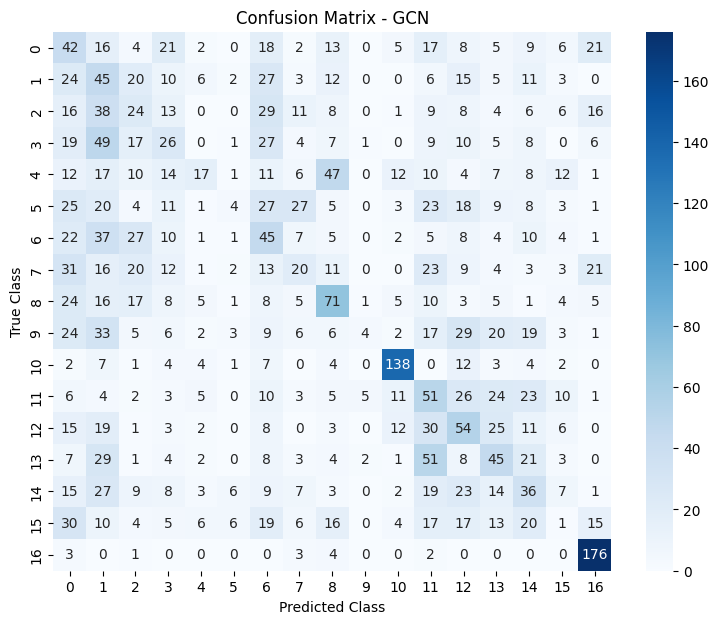

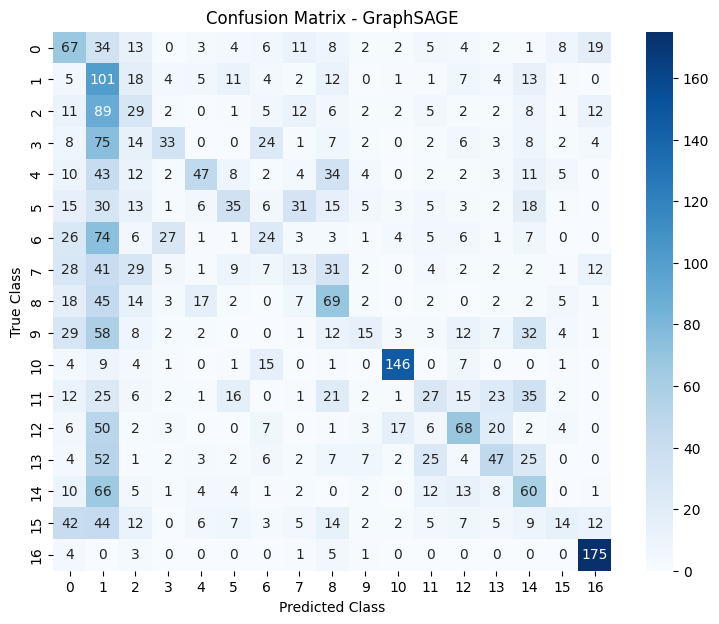

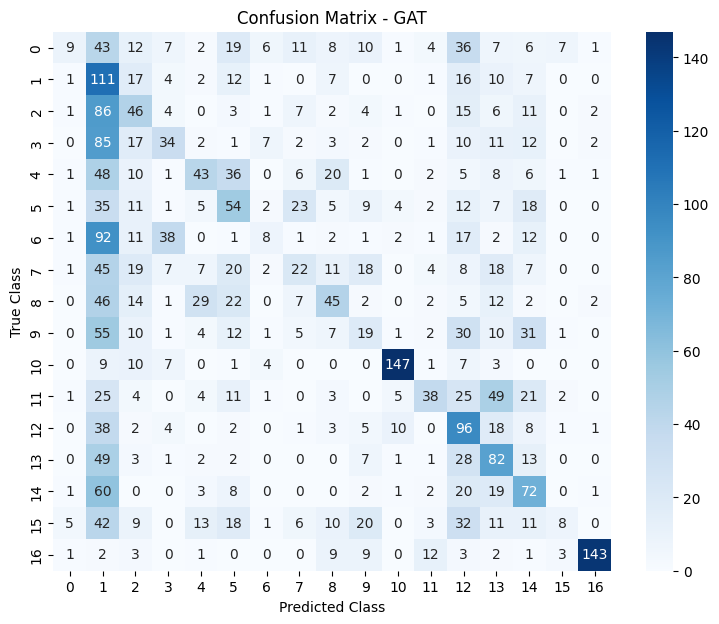

In [33]:
results_for_cm = [

    ("GCN", gcn_result),

    ("GraphSAGE", graphsage_result),

    ("GAT", gat_result)
]

for model_name, result in results_for_cm:

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        result["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "True Class"
    )

    plt.show()

# Final Best Model

In [34]:
best_model_row = final_results.iloc[0]

print("=" * 70)
print("BEST GNN MODEL")
print("=" * 70)

print(
    "Model:",
    best_model_row["Model"]
)

print(
    "Test Accuracy:",
    round(
        best_model_row["Test Accuracy"],
        4
    )
)

print(
    "F1-score:",
    round(
        best_model_row["F1-score"],
        4
    )
)

BEST GNN MODEL
Model: GAT
Test Accuracy: 0.3041
F1-score: 0.2933
